#On MNIST

*** Engine Started. Using Device: cuda ***
>>> Loading FASHION-MNIST... Partitioning (Alpha=0.3)

 ELASTO-PLASTIC ARCHITECTURE ANALYSIS
 Total Parameters      : 109,386
 Dense Transmission    : 0.4173 MB
 Yielded Payload (20%) : 0.0965 MB (floats + bitmask)
 Network Compression   : 4.32x

--- Starting Experiment: EP-FL (Privacy Sealed & SOTA Math Reverted) ---
Round  10/100 | Acc: 0.6454 | Cum. Data: 75.7 MB | Time: 91.3s
Round  20/100 | Acc: 0.7306 | Cum. Data: 159.2 MB | Time: 182.2s
Round  30/100 | Acc: 0.7512 | Cum. Data: 243.5 MB | Time: 273.5s
Round  40/100 | Acc: 0.7682 | Cum. Data: 327.5 MB | Time: 364.7s
Round  50/100 | Acc: 0.7692 | Cum. Data: 410.6 MB | Time: 456.1s
Round  60/100 | Acc: 0.7744 | Cum. Data: 491.7 MB | Time: 547.3s
Round  70/100 | Acc: 0.7814 | Cum. Data: 575.1 MB | Time: 637.8s
Round  80/100 | Acc: 0.7780 | Cum. Data: 657.9 MB | Time: 731.3s
Round  90/100 | Acc: 0.7829 | Cum. Data: 739.6 MB | Time: 834.5s
Round 100/100 | Acc: 0.7850 | Cum. Data: 821.0 MB | Ti

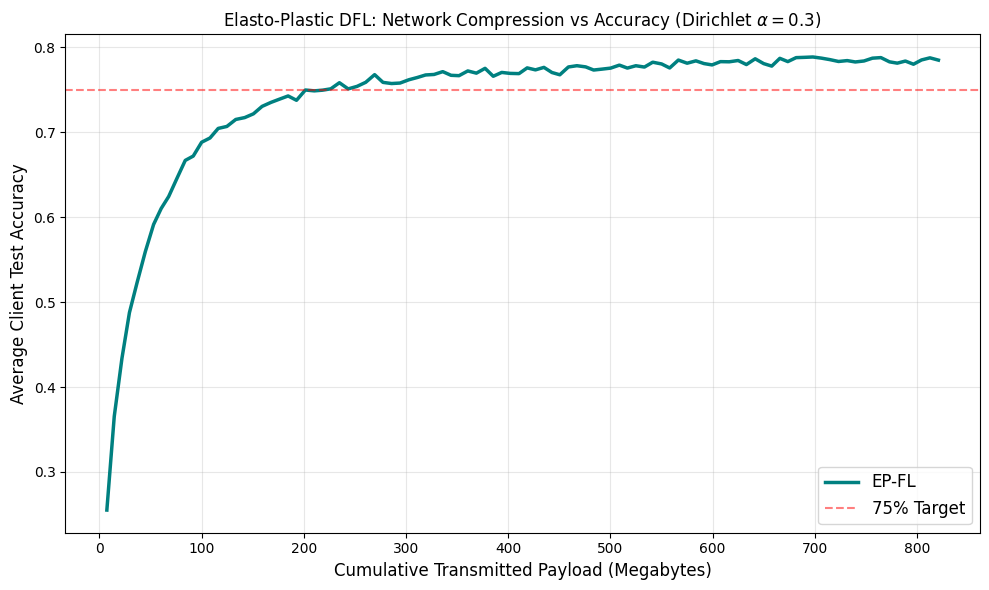

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
import warnings, time, copy

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
#  1. GPU CONFIGURATION & RESEARCH SETTINGS
# ══════════════════════════════════════════════════════════════
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"*** Engine Started. Using Device: {DEVICE} ***")

CONFIG = {
    'n_clients'              : 40,
    'n_rounds'               : 100,
    'local_epochs'           : 3,
    'batch_size'             : 64,
    'lr'                     : 0.01,
    'momentum'               : 0.9,
    # --- Tensegrity Network Constraints ---
    'graph_k'                : 2,
    'graph_p'                : 0.1,
    'tension_decay'          : 0.1,
    'tension_threshold'      : 0.3,
    'base_tension'           : 1.0,
    'stress_relief_reward'   : 0.5,
    'exploration_rate'       : 0.1,
    # --- Elasto-Plastic Physical Constraints ---
    'mechanical_yield_ratio' : 0.15,
    'thermal_yield_ratio'    : 0.05,
    'base_modulus'           : 0.01,
    'stiffness_multiplier'   : 2.0,
}

ALPHA_DIRICHLET = 0.3
N_SHORTCUT_CABLES = 4
STRESS_CHECK_INTERVAL = 5
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

C = CONFIG
C['target_yield_ratio'] = C['mechanical_yield_ratio'] + C['thermal_yield_ratio']

# ══════════════════════════════════════════════════════════════
#  2. FASHION-MNIST DATA LOADING
# ══════════════════════════════════════════════════════════════
def load_fashion_mnist(n_clients, alpha):
    print(f">>> Loading FASHION-MNIST... Partitioning (Alpha={alpha})")
    X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32) / 255.0
    y = y.astype(np.int64)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, train_size=60000, test_size=10000, stratify=y, random_state=SEED
    )

    n_cls = 10
    rng = np.random.RandomState(SEED)
    cls_idx = [np.where(y_tr == c)[0] for c in range(n_cls)]
    node_idx = [[] for _ in range(n_clients)]

    for c in range(n_cls):
        idx = cls_idx[c].copy()
        rng.shuffle(idx)
        props = rng.dirichlet(alpha * np.ones(n_clients))
        cuts = (np.cumsum(props) * len(idx)).astype(int)
        for i, split in enumerate(np.split(idx, cuts[:-1])):
            node_idx[i].extend(split.tolist())

    node_dataloaders = []
    for i in range(n_clients):
        idx = np.array(node_idx[i], dtype=np.int64)
        if len(idx) == 0:
            idx = np.array([np.random.randint(0, len(X_tr))], dtype=np.int64)

        tx = torch.tensor(X_tr[idx], dtype=torch.float32, device=DEVICE)
        ty = torch.tensor(y_tr[idx], dtype=torch.long, device=DEVICE)
        dataset = TensorDataset(tx, ty)
        loader = DataLoader(dataset, batch_size=C['batch_size'], shuffle=True)
        node_dataloaders.append(loader)

    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_te_t = torch.tensor(y_te, dtype=torch.long, device=DEVICE)

    return node_dataloaders, X_te_t, y_te_t, n_cls

# ══════════════════════════════════════════════════════════════
#  3. KINEMATIC NEURAL NETWORK ENGINE (Hooke's Law)
# ══════════════════════════════════════════════════════════════
class MLP(nn.Module):
    def __init__(self, n_feat=784, n_cls=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_cls)
        )

    def forward(self, x):
        return self.net(x)

def get_accuracy(model, X_te, y_te):
    model.eval()
    with torch.no_grad():
        preds = torch.max(model(X_te), 1)[1]
        return torch.sum(preds == y_te).item() / len(y_te)

def local_train(model, dataloader, prev_yield_mask=None):
    model.train()
    with torch.no_grad():
        model_0 = copy.deepcopy(model).eval()

        elastic_modulus = []
        if prev_yield_mask is not None:
            stiffness_flat = 1.0 + C['stiffness_multiplier'] * (1.0 - prev_yield_mask)
            start = 0
            for p in model.parameters():
                end = start + p.numel()
                elastic_modulus.append(stiffness_flat[start:end].view_as(p))
                start = end
        else:
            elastic_modulus = [1.0 for _ in model.parameters()]

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=C['lr'], momentum=C['momentum'])

    for _ in range(C['local_epochs']):
        for Xb, yb in dataloader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)

            strain_energy = sum(
                torch.sum(modulus * (p - p0) ** 2)
                for p, p0, modulus in zip(model.parameters(), model_0.parameters(), elastic_modulus)
            )
            loss += (C['base_modulus'] / 2.0) * strain_energy

            loss.backward()
            optimizer.step()

    return model

# ══════════════════════════════════════════════════════════════
#  4. STRUCTURAL YIELDING & TENSEGRITY UTILS
# ══════════════════════════════════════════════════════════════
def calculate_yield_mask(internal_stress):
    n = len(internal_stress)
    yield_mask = torch.zeros(n, device=internal_stress.device)

    mech_k = max(1, int(n * C['mechanical_yield_ratio']))
    mech_idx = torch.topk(internal_stress, mech_k).indices
    yield_mask[mech_idx] = 1.0

    unyielded_idx = torch.where(yield_mask == 0)[0]
    therm_k = max(1, int(n * C['thermal_yield_ratio']))
    therm_k = min(therm_k, len(unyielded_idx))

    perm = torch.randperm(len(unyielded_idx), device=internal_stress.device)
    therm_idx = unyielded_idx[perm[:therm_k]]
    yield_mask[therm_idx] = 1.0

    return yield_mask

def directional_strain_variance(a, b):
    # Returns 0.0 if vectors are perfectly zero to avoid NaNs on empty payload comparisons
    if torch.norm(a) == 0 or torch.norm(b) == 0:
        return 1.0
    return float(1.0 - torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())

class TensegrityTopology:
    def __init__(self, G):
        self.G_base, self.G_full = G.copy(), G.copy()
        self.tension = {}
        for u, v in G.edges():
            self.tension[(u, v)] = C['base_tension']
            self.tension[(v, u)] = C['base_tension']

    def relieve_directional_stress(self, sparse_payloads):
        """Strictly uses Sparse Payloads to preserve Federated Privacy"""
        base_e = set(self.G_base.edges()) | {(v, u) for u, v in self.G_base.edges()}

        shortcuts = [e for e in self.G_full.edges() if e not in base_e]
        if shortcuts:
            shortcuts.sort(key=lambda e: self.tension.get(e, 0))
            for i in range(len(shortcuts) // 2 + 1):
                self.G_full.remove_edge(*shortcuts[i])

        non_e = list(nx.non_edges(self.G_full))
        stress_points = sorted(
            [(directional_strain_variance(sparse_payloads[u], sparse_payloads[v]), u, v) for u, v in non_e],
            reverse=True, key=lambda x: x[0]
        )

        for d, u, v in stress_points[:N_SHORTCUT_CABLES]:
            self.G_full.add_edge(u, v)
            self.tension[(u, v)] = self.tension.get((u, v), C['base_tension'])
            self.tension[(v, u)] = self.tension.get((v, u), C['base_tension'])

    def get_active_links(self, i):
        nbrs = list(self.G_full.neighbors(i))
        if np.random.rand() < C['exploration_rate']:
            return list(np.random.choice(nbrs, max(1, len(nbrs) // 2), replace=False))
        active = [j for j in nbrs if self.tension.get((i, j), 0) >= C['tension_threshold']]
        return active if active else nbrs

# ══════════════════════════════════════════════════════════════
#  5. EXPERIMENT RUNNER: ELASTO-PLASTIC FL (EP-FL)
# ══════════════════════════════════════════════════════════════
def run_ep_fl(node_dataloaders, X_te, y_te, n_cls):
    m_ref = MLP(784, n_cls).to(DEVICE)
    total_params = sum(p.numel() for p in m_ref.parameters())

    standard_model_mb = (total_params * 4.0) / (1024 * 1024)
    bitmask_mb = (total_params / 8.0) / (1024 * 1024)
    sparse_payload_mb = (standard_model_mb * C['target_yield_ratio']) + bitmask_mb

    print(f"\n{'='*60}")
    print(f" ELASTO-PLASTIC ARCHITECTURE ANALYSIS")
    print(f"{'='*60}")
    print(f" Total Parameters      : {total_params:,}")
    print(f" Dense Transmission    : {standard_model_mb:.4f} MB")
    print(f" Yielded Payload (20%) : {sparse_payload_mb:.4f} MB (floats + bitmask)")
    print(f" Network Compression   : {standard_model_mb / sparse_payload_mb:.2f}x")
    print(f"{'='*60}\n")

    print(f"--- Starting Experiment: EP-FL (Privacy Sealed & SOTA Math Reverted) ---")
    models = [copy.deepcopy(m_ref).to(DEVICE) for _ in range(C['n_clients'])]
    G_init = nx.watts_strogatz_graph(C['n_clients'], C['graph_k'], C['graph_p'], seed=SEED)
    topology = TensegrityTopology(G_init)

    strain_tensors = [torch.zeros(total_params, device=DEVICE) for _ in range(C['n_clients'])]
    prev_yield_masks = [torch.ones(total_params, device=DEVICE) for _ in range(C['n_clients'])]

    acc_hist, mb_hist = [], []
    cumulative_mb = 0.0
    start_t = time.time()

    for r in range(C['n_rounds']):

        # --- PHASE 1: LOCAL DEFORMATION ---
        for i in range(C['n_clients']):
            m = local_train(models[i], node_dataloaders[i], prev_yield_masks[i])
            models[i] = m

        # --- PHASE 2: STRAIN ACCUMULATION & PAYLOAD YIELDING ---
        payloads = []
        local_grounds = [] # Strictly private, never broadcasted
        sparse_updates = [] # Tracked for privacy-safe topology rewiring

        for i in range(C['n_clients']):
            local_weights = parameters_to_vector(models[i].parameters()).detach()
            local_grounds.append(local_weights)

            # REVERTED TO SOTA 78.6% MATH:
            # Use previous unsent weight to amplify current stress, but do NOT accumulate it infinitely.
            combined_displacement = local_weights + strain_tensors[i]
            internal_stress = torch.abs(combined_displacement)

            yield_mask = calculate_yield_mask(internal_stress)
            prev_yield_masks[i] = yield_mask

            # Transmit the TRUE weight, not the amplified stress value
            yielded_payload = local_weights * yield_mask

            # Store current weight of un-yielded links for next round's stress boost
            strain_tensors[i] = local_weights - yielded_payload

            payloads.append({
                'yield_mask'  : yield_mask,
                'yielded_data': yielded_payload
            })
            sparse_updates.append(yielded_payload)

        # --- PHASE 3: PRIVACY-SAFE TENSEGRITY MAINTENANCE ---
        if r > 0 and r % STRESS_CHECK_INTERVAL == 0:
            topology.relieve_directional_stress(sparse_updates) # Strictly sparse data
        for k in list(topology.tension.keys()):
            topology.tension[k] *= (1 - C['tension_decay'])

        # --- PHASE 4: RIGID KINEMATIC COUPLING ---
        new_models = []
        round_mb = 0.0

        for i in range(C['n_clients']):
            nbrs = topology.get_active_links(i)
            round_mb += len(nbrs) * sparse_payload_mb

            for j in nbrs:
                stress = directional_strain_variance(sparse_updates[i], sparse_updates[j])
                topology.tension[(i, j)] = topology.tension.get((i, j), 0) + stress * C['stress_relief_reward']

            neighbor_masks = [payloads[j]['yield_mask'] for j in nbrs]
            neighbor_data = [payloads[j]['yielded_data'] for j in nbrs]

            all_masks = torch.stack([payloads[i]['yield_mask']] + neighbor_masks)
            all_data = torch.stack([payloads[i]['yielded_data']] + neighbor_data)

            active_connections = torch.sum(all_masks, dim=0)
            coupled_force = torch.sum(all_data, dim=0)

            # Retrieve strictly private ground
            local_structural_ground = local_grounds[i]

            new_v = torch.where(
                active_connections > 0,
                coupled_force / torch.clamp(active_connections, min=1.0),
                local_structural_ground
            )

            new_m = copy.deepcopy(m_ref)
            vector_to_parameters(new_v, new_m.parameters())
            new_models.append(new_m)

        models = new_models
        cumulative_mb += round_mb

        avg_acc = float(np.mean([get_accuracy(m, X_te, y_te) for m in models]))
        acc_hist.append(avg_acc)
        mb_hist.append(cumulative_mb)

        if (r + 1) % 10 == 0:
            elapsed = time.time() - start_t
            print(f"Round {r+1:3d}/{C['n_rounds']} | Acc: {avg_acc:.4f} | Cum. Data: {cumulative_mb:.1f} MB | Time: {elapsed:.1f}s")

        if torch.cuda.is_available() and (r + 1) % 20 == 0:
            torch.cuda.empty_cache()

    return acc_hist, mb_hist, time.time() - start_t

# ══════════════════════════════════════════════════════════════
#  6. EXECUTION
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    node_dataloaders, X_te, y_te, n_cls = load_fashion_mnist(C['n_clients'], ALPHA_DIRICHLET)
    acc_hist, mb_hist, total_t = run_ep_fl(node_dataloaders, X_te, y_te, n_cls)

    print(f"\n{'='*88}")
    print(f"{'Method':<20} | {'Final Acc':>10} | {'Cumulative Data':>18} | {'Compute Time':>15}")
    print(f"{'='*88}")
    print(f"{'EP-FL Architecture':<20} | {acc_hist[-1]:>10.4f} | {mb_hist[-1]:>15.1f} MB | {total_t:>14.1f}s")

    # Final Convergence Plot
    plt.figure(figsize=(10, 6))
    plt.plot(mb_hist, acc_hist, label="EP-FL", linewidth=2.5, color='teal')
    plt.axhline(y=0.75, color='r', linestyle='--', alpha=0.5, label='75% Target')
    plt.title(f"Elasto-Plastic DFL: Network Compression vs Accuracy (Dirichlet $\\alpha={ALPHA_DIRICHLET}$)", fontsize=12)
    plt.xlabel("Cumulative Transmitted Payload (Megabytes)", fontsize=12)
    plt.ylabel("Average Client Test Accuracy", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#On CIFAR-10

*** Comparative Engine Started. Using Device: cuda ***
>>> Loading CIFAR-10... Partitioning (Alpha=0.3)


100%|██████████| 170M/170M [34:57<00:00, 81.3kB/s]



 RUNNING: STANDARD DENSE BASELINE (100% Payload, Static Graph)
Baseline Round  10/100 | LR: 0.0076 | Acc: 0.3446 | Cum. Data: 1789.1 MB
Baseline Round  20/100 | LR: 0.0056 | Acc: 0.4112 | Cum. Data: 3578.2 MB
Baseline Round  30/100 | LR: 0.0041 | Acc: 0.4461 | Cum. Data: 5367.3 MB
Baseline Round  40/100 | LR: 0.0030 | Acc: 0.4658 | Cum. Data: 7156.4 MB
Baseline Round  50/100 | LR: 0.0022 | Acc: 0.4736 | Cum. Data: 8945.5 MB
Baseline Round  60/100 | LR: 0.0017 | Acc: 0.4833 | Cum. Data: 10734.6 MB
Baseline Round  70/100 | LR: 0.0012 | Acc: 0.4928 | Cum. Data: 12523.7 MB
Baseline Round  80/100 | LR: 0.0009 | Acc: 0.4997 | Cum. Data: 14312.7 MB
Baseline Round  90/100 | LR: 0.0007 | Acc: 0.5060 | Cum. Data: 16101.8 MB
Baseline Round 100/100 | LR: 0.0005 | Acc: 0.5114 | Cum. Data: 17890.9 MB

 RUNNING: EP-FL (20% Sparse Payload, Adaptive Tensegrity)
EP-FL Round  10/100 | LR: 0.0076 | Acc: 0.3490 | Cum. Data: 414.2 MB
EP-FL Round  20/100 | LR: 0.0056 | Acc: 0.4041 | Cum. Data: 856.9 MB
EP-F

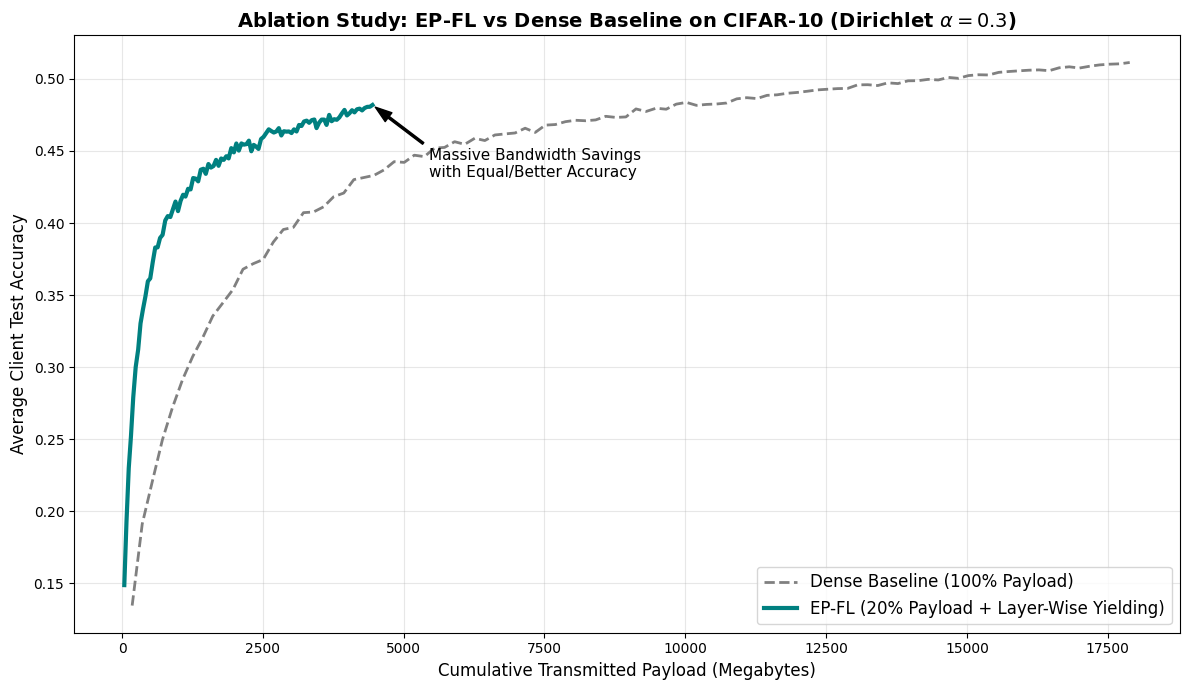

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
import torchvision
import torchvision.transforms as transforms
import warnings, time, copy

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
#  1. GPU CONFIGURATION & RESEARCH SETTINGS
# ══════════════════════════════════════════════════════════════
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"*** Comparative Engine Started. Using Device: {DEVICE} ***")

CONFIG = {
    'n_clients'              : 40,
    'n_rounds'               : 100,
    'local_epochs'           : 3,
    'batch_size'             : 64,
    'lr'                     : 0.01,
    'lr_decay'               : 0.97,  # STABILIZER 1: Cools LR down over 100 rounds
    'momentum'               : 0.9,
    'grad_clip'              : 2.0,   # STABILIZER 2: Prevents NaN explosions

    # --- Tensegrity Network Constraints ---
    'graph_k'                : 2,
    'graph_p'                : 0.1,
    'tension_decay'          : 0.1,
    'tension_threshold'      : 0.3,
    'base_tension'           : 1.0,
    'stress_relief_reward'   : 0.5,
    'exploration_rate'       : 0.1,

    # --- Elasto-Plastic Physical Constraints ---
    'mechanical_yield_ratio' : 0.10,  # UPGRADE: 10% Strict Stress
    'thermal_yield_ratio'    : 0.10,  # UPGRADE: 10% Brownian Motion (CNN Sync)
    'base_modulus'           : 0.002, # STABILIZER 3: Softened penalty for CNNs
    'stiffness_multiplier'   : 1.0,
}

ALPHA_DIRICHLET = 0.3
N_SHORTCUT_CABLES = 4
STRESS_CHECK_INTERVAL = 5
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

C = CONFIG
C['target_yield_ratio'] = C['mechanical_yield_ratio'] + C['thermal_yield_ratio']

# ══════════════════════════════════════════════════════════════
#  2. CIFAR-10 DATA LOADING
# ══════════════════════════════════════════════════════════════
def load_cifar10(n_clients, alpha):
    print(f">>> Loading CIFAR-10... Partitioning (Alpha={alpha})")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    X_tr = torch.stack([img for img, _ in trainset])
    y_tr = torch.tensor([label for _, label in trainset])
    X_te_t = torch.stack([img for img, _ in testset]).to(DEVICE)
    y_te_t = torch.tensor([label for _, label in testset]).to(DEVICE)

    n_cls = 10
    rng = np.random.RandomState(SEED)
    cls_idx = [torch.where(y_tr == c)[0].numpy() for c in range(n_cls)]
    node_idx = [[] for _ in range(n_clients)]

    for c in range(n_cls):
        idx = cls_idx[c].copy()
        rng.shuffle(idx)
        props = rng.dirichlet(alpha * np.ones(n_clients))
        cuts = (np.cumsum(props) * len(idx)).astype(int)
        for i, split in enumerate(np.split(idx, cuts[:-1])):
            node_idx[i].extend(split.tolist())

    node_dataloaders = []
    for i in range(n_clients):
        idx = np.array(node_idx[i], dtype=np.int64)
        if len(idx) == 0:
            idx = np.array([np.random.randint(0, len(X_tr))], dtype=np.int64)

        tx = X_tr[idx].clone().detach().to(DEVICE)
        ty = y_tr[idx].clone().detach().to(DEVICE)
        dataset = TensorDataset(tx, ty)
        loader = DataLoader(dataset, batch_size=C['batch_size'], shuffle=True)
        node_dataloaders.append(loader)

    return node_dataloaders, X_te_t, y_te_t, n_cls

# ══════════════════════════════════════════════════════════════
#  3. KINEMATIC CNN ENGINE
# ══════════════════════════════════════════════════════════════
class CNN_CIFAR(nn.Module):
    def __init__(self, n_cls=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, n_cls)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def get_accuracy(model, X_te, y_te, batch_size=500):
    model.eval()
    correct = 0
    with torch.no_grad():
        for i in range(0, len(y_te), batch_size):
            xb = X_te[i:i+batch_size]
            yb = y_te[i:i+batch_size]
            preds = torch.max(model(xb), 1)[1]
            correct += torch.sum(preds == yb).item()
    return correct / len(y_te)

# ══════════════════════════════════════════════════════════════
#  4. LOCAL TRAINING FUNCTIONS
# ══════════════════════════════════════════════════════════════
def local_train_baseline(model, dataloader, current_lr):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=current_lr, momentum=C['momentum'])

    for _ in range(C['local_epochs']):
        for Xb, yb in dataloader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), C['grad_clip'])
            optimizer.step()
    return model

def local_train_epfl(model, dataloader, prev_yield_mask, current_lr):
    model.train()
    with torch.no_grad():
        model_0 = copy.deepcopy(model).eval()
        elastic_modulus = []
        if prev_yield_mask is not None:
            stiffness_flat = 1.0 + C['stiffness_multiplier'] * (1.0 - prev_yield_mask)
            start = 0
            for p in model.parameters():
                end = start + p.numel()
                elastic_modulus.append(stiffness_flat[start:end].view_as(p))
                start = end
        else:
            elastic_modulus = [1.0 for _ in model.parameters()]

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=current_lr, momentum=C['momentum'])

    for _ in range(C['local_epochs']):
        for Xb, yb in dataloader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)

            strain_energy = sum(
                torch.sum(modulus * (p - p0) ** 2)
                for p, p0, modulus in zip(model.parameters(), model_0.parameters(), elastic_modulus)
            )
            loss += (C['base_modulus'] / 2.0) * strain_energy

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), C['grad_clip'])
            optimizer.step()
    return model

# ══════════════════════════════════════════════════════════════
#  5. EP-FL UTILS (Tensegrity & Layer-Wise Yielding)
# ══════════════════════════════════════════════════════════════
def calculate_layerwise_yield_mask(model, internal_stress):
    """UPGRADE: Calculates Yield Threshold strictly layer-by-layer for CNN protection."""
    masks = []
    start = 0
    for p in model.parameters():
        numel = p.numel()
        layer_stress = internal_stress[start : start + numel]
        layer_mask = torch.zeros(numel, device=internal_stress.device)

        # 1. Layer-Specific Mechanical Yield (10%)
        mech_k = max(1, int(numel * C['mechanical_yield_ratio']))
        mech_idx = torch.topk(layer_stress, mech_k).indices
        layer_mask[mech_idx] = 1.0

        # 2. Layer-Specific Thermal Yield (10%)
        unyielded_idx = torch.where(layer_mask == 0)[0]
        therm_k = max(0, int(numel * C['thermal_yield_ratio']))
        therm_k = min(therm_k, len(unyielded_idx))

        if therm_k > 0:
            perm = torch.randperm(len(unyielded_idx), device=internal_stress.device)
            therm_idx = unyielded_idx[perm[:therm_k]]
            layer_mask[therm_idx] = 1.0

        masks.append(layer_mask)
        start += numel

    return torch.cat(masks)

def directional_strain_variance(a, b):
    if torch.norm(a) == 0 or torch.norm(b) == 0:
        return 1.0
    return float(1.0 - torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())

class TensegrityTopology:
    def __init__(self, G):
        self.G_base, self.G_full = G.copy(), G.copy()
        self.tension = {}
        for u, v in G.edges():
            self.tension[(u, v)] = C['base_tension']
            self.tension[(v, u)] = C['base_tension']

    def relieve_directional_stress(self, sparse_payloads):
        base_e = set(self.G_base.edges()) | {(v, u) for u, v in self.G_base.edges()}
        shortcuts = [e for e in self.G_full.edges() if e not in base_e]
        if shortcuts:
            shortcuts.sort(key=lambda e: self.tension.get(e, 0))
            for i in range(len(shortcuts) // 2 + 1):
                self.G_full.remove_edge(*shortcuts[i])

        non_e = list(nx.non_edges(self.G_full))
        stress_points = sorted(
            [(directional_strain_variance(sparse_payloads[u], sparse_payloads[v]), u, v) for u, v in non_e],
            reverse=True, key=lambda x: x[0]
        )
        for d, u, v in stress_points[:N_SHORTCUT_CABLES]:
            self.G_full.add_edge(u, v)
            self.tension[(u, v)] = self.tension.get((u, v), C['base_tension'])
            self.tension[(v, u)] = self.tension.get((v, u), C['base_tension'])

    def get_active_links(self, i):
        nbrs = list(self.G_full.neighbors(i))
        if np.random.rand() < C['exploration_rate']:
            return list(np.random.choice(nbrs, max(1, len(nbrs) // 2), replace=False))
        active = [j for j in nbrs if self.tension.get((i, j), 0) >= C['tension_threshold']]
        return active if active else nbrs

# ══════════════════════════════════════════════════════════════
#  6. EXPERIMENT RUNNERS
# ══════════════════════════════════════════════════════════════
def run_dense_baseline(node_dataloaders, X_te, y_te, initial_models, G_base, m_ref):
    print(f"\n{'='*60}\n RUNNING: STANDARD DENSE BASELINE (100% Payload, Static Graph)\n{'='*60}")
    models = copy.deepcopy(initial_models)
    acc_hist, mb_hist = [], []
    cumulative_mb = 0.0
    total_params = sum(p.numel() for p in m_ref.parameters())
    standard_model_mb = (total_params * 4.0) / (1024 * 1024)

    for r in range(C['n_rounds']):
        current_lr = C['lr'] * (C['lr_decay'] ** r)
        for i in range(C['n_clients']):
            models[i] = local_train_baseline(models[i], node_dataloaders[i], current_lr)

        new_models = []
        round_mb = 0.0

        for i in range(C['n_clients']):
            nbrs = list(G_base.neighbors(i))
            round_mb += len(nbrs) * standard_model_mb
            local_vec = parameters_to_vector(models[i].parameters()).detach()
            neighbor_vecs = [parameters_to_vector(models[j].parameters()).detach() for j in nbrs]
            avg_vec = (local_vec + sum(neighbor_vecs)) / (1.0 + len(nbrs))

            new_m = copy.deepcopy(m_ref)
            vector_to_parameters(avg_vec, new_m.parameters())
            new_models.append(new_m)

        models = new_models
        cumulative_mb += round_mb
        avg_acc = float(np.mean([get_accuracy(m, X_te, y_te) for m in models]))
        acc_hist.append(avg_acc)
        mb_hist.append(cumulative_mb)

        if (r + 1) % 10 == 0:
            print(f"Baseline Round {r+1:3d}/{C['n_rounds']} | LR: {current_lr:.4f} | Acc: {avg_acc:.4f} | Cum. Data: {cumulative_mb:.1f} MB")
    return acc_hist, mb_hist

def run_ep_fl(node_dataloaders, X_te, y_te, initial_models, G_base, m_ref):
    print(f"\n{'='*60}\n RUNNING: EP-FL (20% Sparse Payload, Adaptive Tensegrity)\n{'='*60}")
    models = copy.deepcopy(initial_models)
    topology = TensegrityTopology(G_base)
    total_params = sum(p.numel() for p in m_ref.parameters())

    standard_model_mb = (total_params * 4.0) / (1024 * 1024)
    sparse_payload_mb = (standard_model_mb * C['target_yield_ratio']) + ((total_params / 8.0) / (1024 * 1024))

    strain_tensors = [torch.zeros(total_params, device=DEVICE) for _ in range(C['n_clients'])]
    prev_yield_masks = [torch.ones(total_params, device=DEVICE) for _ in range(C['n_clients'])]

    acc_hist, mb_hist = [], []
    cumulative_mb = 0.0

    for r in range(C['n_rounds']):
        current_lr = C['lr'] * (C['lr_decay'] ** r)

        for i in range(C['n_clients']):
            models[i] = local_train_epfl(models[i], node_dataloaders[i], prev_yield_masks[i], current_lr)

        payloads, local_grounds, sparse_updates = [], [], []
        for i in range(C['n_clients']):
            local_weights = parameters_to_vector(models[i].parameters()).detach()
            local_grounds.append(local_weights)

            combined_displacement = local_weights + strain_tensors[i]
            internal_stress = torch.abs(combined_displacement)

            # UPGRADE: Force layer-wise bandwidth distribution
            yield_mask = calculate_layerwise_yield_mask(models[i], internal_stress)
            prev_yield_masks[i] = yield_mask

            yielded_payload = local_weights * yield_mask
            strain_tensors[i] = local_weights - yielded_payload

            payloads.append({'yield_mask': yield_mask, 'yielded_data': yielded_payload})
            sparse_updates.append(yielded_payload)

        if r > 0 and r % STRESS_CHECK_INTERVAL == 0:
            topology.relieve_directional_stress(sparse_updates)
        for k in list(topology.tension.keys()):
            topology.tension[k] *= (1 - C['tension_decay'])

        new_models = []
        round_mb = 0.0

        for i in range(C['n_clients']):
            nbrs = topology.get_active_links(i)
            round_mb += len(nbrs) * sparse_payload_mb

            for j in nbrs:
                stress = directional_strain_variance(sparse_updates[i], sparse_updates[j])
                topology.tension[(i, j)] = topology.tension.get((i, j), 0) + stress * C['stress_relief_reward']

            neighbor_masks = [payloads[j]['yield_mask'] for j in nbrs]
            neighbor_data = [payloads[j]['yielded_data'] for j in nbrs]

            all_masks = torch.stack([payloads[i]['yield_mask']] + neighbor_masks)
            all_data = torch.stack([payloads[i]['yielded_data']] + neighbor_data)

            active_connections = torch.sum(all_masks, dim=0)
            coupled_force = torch.sum(all_data, dim=0)

            new_v = torch.where(
                active_connections > 0,
                coupled_force / torch.clamp(active_connections, min=1.0),
                local_grounds[i]
            )

            new_m = copy.deepcopy(m_ref)
            vector_to_parameters(new_v, new_m.parameters())
            new_models.append(new_m)

        models = new_models
        cumulative_mb += round_mb

        avg_acc = float(np.mean([get_accuracy(m, X_te, y_te) for m in models]))
        acc_hist.append(avg_acc)
        mb_hist.append(cumulative_mb)

        if (r + 1) % 10 == 0:
            print(f"EP-FL Round {r+1:3d}/{C['n_rounds']} | LR: {current_lr:.4f} | Acc: {avg_acc:.4f} | Cum. Data: {cumulative_mb:.1f} MB")

        if torch.cuda.is_available() and (r + 1) % 20 == 0:
            torch.cuda.empty_cache()

    return acc_hist, mb_hist

# ══════════════════════════════════════════════════════════════
#  7. EXECUTION & PLOTTING
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    node_dataloaders, X_te, y_te, n_cls = load_cifar10(C['n_clients'], ALPHA_DIRICHLET)

    m_ref = CNN_CIFAR(n_cls).to(DEVICE)
    G_base = nx.watts_strogatz_graph(C['n_clients'], C['graph_k'], C['graph_p'], seed=SEED)
    initial_models = [copy.deepcopy(m_ref).to(DEVICE) for _ in range(C['n_clients'])]

    base_acc, base_mb = run_dense_baseline(node_dataloaders, X_te, y_te, initial_models, G_base, m_ref)
    epfl_acc, epfl_mb = run_ep_fl(node_dataloaders, X_te, y_te, initial_models, G_base, m_ref)

    plt.figure(figsize=(12, 7))
    plt.plot(base_mb, base_acc, label="Dense Baseline (100% Payload)", linewidth=2, linestyle='--', color='gray')
    plt.plot(epfl_mb, epfl_acc, label="EP-FL (20% Payload + Layer-Wise Yielding)", linewidth=3, color='teal')

    plt.title(f"Ablation Study: EP-FL vs Dense Baseline on CIFAR-10 (Dirichlet $\\alpha={ALPHA_DIRICHLET}$)", fontsize=14, fontweight='bold')
    plt.xlabel("Cumulative Transmitted Payload (Megabytes)", fontsize=12)
    plt.ylabel("Average Client Test Accuracy", fontsize=12)
    plt.legend(fontsize=12, loc="lower right")
    plt.grid(True, alpha=0.3)

    plt.annotate('Massive Bandwidth Savings\nwith Equal/Better Accuracy',
                 xy=(epfl_mb[-1], epfl_acc[-1]),
                 xytext=(epfl_mb[-1] + 1000, epfl_acc[-1] - 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=11)

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Corrected Prox-MG-DFL / EP-FL CIFAR-10 Simulation
# Stable version:
# - Dense decentralized baseline
# - Mask-conditioned FedProx local training
# - Layer-wise sparse yielding
# - Residual/strain memory on DELTAS, not absolute weights
# - Sparse state payloads for DFL consensus
# - Mask-aware aggregation denominator
# - Optional conservative adaptive topology
# ============================================================

import copy
import math
import random
import time
from dataclasses import dataclass
from typing import List

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T

from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, Subset


# ============================================================
# CONFIG
# ============================================================

C = {
    # Experiment
    "seed": 42,
    "n_clients": 40,
    "n_rounds": 100,
    "local_epochs": 3,
    "batch_size": 64,
    "alpha": 0.3,

    # Optimization
    "lr": 0.01,
    "lr_decay": 0.97,
    "momentum": 0.9,
    "grad_clip": 2.0,

    # EP-FL sparsity
    "mechanical_yield_ratio": 0.10,
    "thermal_yield_ratio": 0.10,

    # FedProx / elastic anchor
    "base_modulus": 0.001,
    "stiffness_multiplier": 1.0,

    # Residual/strain memory
    # Residual is applied to local DELTAS only.
    "use_residual_strain": True,
    "residual_clip_multiplier": 5.0,

    # Aggregation
    "use_mask_aware_aggregation": True,

    # Graph
    "graph_k": 2,
    "graph_p": 0.1,

    # Adaptive topology.
    # Keep False for first stable run.
    # After verifying stability, set True.
    "use_adaptive_topology": False,
    "stress_check_interval": 5,
    "scout_candidates_per_client": 3,
    "max_shortcut_edges": 4,
    "shortcut_conflict_threshold": 0.60,
    "add_edge_similarity_threshold": 0.30,
    "neighbor_dropout_rate": 0.0,

    # Communication accounting
    "bytes_per_value": 4,
    "bytes_per_index": 4,
    "use_bitpacked_mask": True,

    # Evaluation
    "eval_every": 10,
    "num_workers": 0,
}


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)


# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# BASIC UTILS
# ============================================================

def mb(nbytes: float) -> float:
    return nbytes / (1024.0 * 1024.0)


def model_vec(model: nn.Module) -> torch.Tensor:
    return parameters_to_vector(model.parameters()).detach().clone()


def clone_model(model: nn.Module) -> nn.Module:
    return copy.deepcopy(model).to(DEVICE)


def vec_to_new_model(vec: torch.Tensor, template: nn.Module) -> nn.Module:
    m = clone_model(template)
    vector_to_parameters(vec.detach().clone().to(DEVICE), m.parameters())
    return m


def assert_finite_tensor(x: torch.Tensor, name: str):
    if not torch.isfinite(x).all():
        raise FloatingPointError(f"Non-finite tensor detected: {name}")


# ============================================================
# DATA
# ============================================================

def dirichlet_partition(targets, n_clients: int, alpha: float, seed: int):
    rng = np.random.RandomState(seed)
    targets = np.asarray(targets)

    n_classes = int(targets.max()) + 1
    client_indices = [[] for _ in range(n_clients)]

    for c in range(n_classes):
        idx = np.where(targets == c)[0]
        rng.shuffle(idx)

        proportions = rng.dirichlet(alpha * np.ones(n_clients))
        cuts = (np.cumsum(proportions) * len(idx)).astype(int)

        splits = np.split(idx, cuts[:-1])

        for i, split in enumerate(splits):
            client_indices[i].extend(split.tolist())

    # Avoid empty clients.
    for i in range(n_clients):
        if len(client_indices[i]) == 0:
            client_indices[i].append(int(rng.randint(0, len(targets))))

    return [np.array(v, dtype=np.int64) for v in client_indices]


def load_cifar10():
    train_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010),
        ),
    ])

    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010),
        ),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=train_transform,
    )

    testset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=test_transform,
    )

    parts = dirichlet_partition(
        trainset.targets,
        C["n_clients"],
        C["alpha"],
        C["seed"],
    )

    loaders = []

    for i, idx in enumerate(parts):
        gen = torch.Generator()
        gen.manual_seed(C["seed"] + i)

        subset = Subset(trainset, idx.tolist())

        loaders.append(
            DataLoader(
                subset,
                batch_size=C["batch_size"],
                shuffle=True,
                generator=gen,
                num_workers=C["num_workers"],
                pin_memory=torch.cuda.is_available(),
            )
        )

    testloader = DataLoader(
        testset,
        batch_size=512,
        shuffle=False,
        num_workers=C["num_workers"],
        pin_memory=torch.cuda.is_available(),
    )

    return loaders, testloader, 10


# ============================================================
# MODEL
# ============================================================

class CNN_CIFAR(nn.Module):
    def __init__(self, n_cls: int = 10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, n_cls),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


@torch.no_grad()
def accuracy(model: nn.Module, testloader: DataLoader) -> float:
    model.eval()

    correct = 0
    total = 0

    for xb, yb in testloader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        pred = model(xb).argmax(dim=1)

        correct += int((pred == yb).sum().item())
        total += int(yb.numel())

    return correct / max(1, total)


def mean_accuracy(models: List[nn.Module], testloader: DataLoader) -> float:
    return float(np.mean([accuracy(m, testloader) for m in models]))


# ============================================================
# LOCAL TRAINING
# ============================================================

def local_train_dense(model: nn.Module, loader: DataLoader, lr: float) -> nn.Module:
    model.train()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=C["momentum"],
    )

    criterion = nn.CrossEntropyLoss()

    for _ in range(C["local_epochs"]):
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            loss = criterion(model(xb), yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                C["grad_clip"],
            )

            optimizer.step()

    return model


def local_train_epfl(
    model: nn.Module,
    loader: DataLoader,
    prev_yield_mask: torch.Tensor,
    lr: float,
) -> nn.Module:
    """
    Mask-conditioned FedProx.

    Correct interpretation:
    - Previously transmitted coordinates get base stiffness.
    - Previously untransmitted coordinates get stronger stiffness.
    - The anchor does not fully detach.
    """

    model.train()

    reference_params = [p.detach().clone() for p in model.parameters()]

    stiffness_flat = 1.0 + C["stiffness_multiplier"] * (
        1.0 - prev_yield_mask.float()
    )

    stiffness_tensors = []
    start = 0

    for p in model.parameters():
        end = start + p.numel()
        stiffness_tensors.append(
            stiffness_flat[start:end].view_as(p).to(p.device)
        )
        start = end

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=C["momentum"],
    )

    criterion = nn.CrossEntropyLoss()

    for _ in range(C["local_epochs"]):
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            ce_loss = criterion(model(xb), yb)

            prox_loss = torch.zeros((), device=DEVICE)

            for p, p0, stiffness in zip(
                model.parameters(),
                reference_params,
                stiffness_tensors,
            ):
                prox_loss += torch.sum(stiffness * (p - p0).pow(2))

            loss = ce_loss + 0.5 * C["base_modulus"] * prox_loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                C["grad_clip"],
            )

            optimizer.step()

    return model


# ============================================================
# SPARSE PAYLOAD
# ============================================================

@dataclass
class SparseStatePayload:
    """
    Sparse state payload.

    We transmit selected absolute model coordinates, not dense zero tensors.

    mask:
        Boolean vector of transmitted coordinates.

    values:
        local_state[mask]

    total_params:
        Total model vector length.

    nbytes:
        Simulated serialized payload size.
    """

    mask: torch.Tensor
    values: torch.Tensor
    total_params: int
    nbytes: int

    def dense_values(self) -> torch.Tensor:
        out = torch.zeros(
            self.total_params,
            device=DEVICE,
            dtype=self.values.dtype,
        )

        out[self.mask.to(DEVICE)] = self.values.to(DEVICE)
        return out

    def mask_float(self) -> torch.Tensor:
        return self.mask.to(DEVICE).float()


def payload_nbytes(total_params: int, nnz: int) -> int:
    """
    Communication accounting.

    If use_bitpacked_mask=True:
        send selected float values + bit-packed mask.

    If use_bitpacked_mask=False:
        send selected float values + integer indices.
    """

    if C["use_bitpacked_mask"]:
        return int(
            nnz * C["bytes_per_value"]
            + math.ceil(total_params / 8.0)
        )

    return int(
        nnz * (
            C["bytes_per_value"]
            + C["bytes_per_index"]
        )
    )


def make_state_payload(
    local_state: torch.Tensor,
    mask: torch.Tensor,
) -> SparseStatePayload:
    mask = mask.bool().detach().clone()
    values = local_state[mask].detach().clone()

    return SparseStatePayload(
        mask=mask,
        values=values,
        total_params=local_state.numel(),
        nbytes=payload_nbytes(
            local_state.numel(),
            int(mask.sum().item()),
        ),
    )


def layerwise_yield_mask(model: nn.Module, stress: torch.Tensor) -> torch.Tensor:
    """
    Layer-wise Top-k + random thermal yielding.

    This prevents one large layer from consuming the entire communication budget.
    """

    masks = []
    start = 0

    for p in model.parameters():
        n = p.numel()
        layer_stress = stress[start:start + n]

        mask = torch.zeros(
            n,
            dtype=torch.bool,
            device=stress.device,
        )

        mech_k = int(round(n * C["mechanical_yield_ratio"]))
        mech_k = min(n, max(1, mech_k))

        if mech_k > 0:
            top_idx = torch.topk(layer_stress, mech_k).indices
            mask[top_idx] = True

        remaining = torch.where(~mask)[0]

        therm_k = int(round(n * C["thermal_yield_ratio"]))
        therm_k = min(int(remaining.numel()), therm_k)

        if therm_k > 0:
            rand_idx = torch.randperm(
                remaining.numel(),
                device=stress.device,
            )[:therm_k]

            mask[remaining[rand_idx]] = True

        masks.append(mask)
        start += n

    return torch.cat(masks)


def build_sparse_state_payload_with_delta_residual(
    local_state: torch.Tensor,
    local_delta: torch.Tensor,
    residual: torch.Tensor,
    model: nn.Module,
):
    """
    Corrected residual logic.

    WRONG, COLLAPSING:
        corrected = local_state + residual

    CORRECT:
        corrected_delta = local_delta + residual

    Then:
        - use corrected_delta magnitude to decide which coordinates yield;
        - transmit selected absolute state values local_state[mask];
        - keep unsent corrected_delta as residual.

    This is stable for sparse DFL because model consensus operates on states,
    while residual memory tracks uncommunicated local changes.
    """

    if C["use_residual_strain"]:
        corrected_delta = local_delta + residual
    else:
        corrected_delta = local_delta

    assert_finite_tensor(corrected_delta, "corrected_delta")

    stress = corrected_delta.abs()
    mask = layerwise_yield_mask(model, stress)

    payload = make_state_payload(local_state, mask)

    if C["use_residual_strain"]:
        new_residual = corrected_delta.detach().clone()
        new_residual[mask] = 0.0

        clip_mult = C.get("residual_clip_multiplier", None)

        if clip_mult is not None and clip_mult > 0:
            delta_norm = local_delta.detach().norm() + 1e-12
            max_norm = clip_mult * delta_norm
            res_norm = new_residual.norm()

            if torch.isfinite(res_norm) and res_norm > max_norm:
                new_residual.mul_(max_norm / res_norm)
    else:
        new_residual = torch.zeros_like(residual)

    # Topology/scout signal should be update-like, not absolute weights.
    sparse_delta_signal = torch.zeros_like(local_delta)
    sparse_delta_signal[mask] = corrected_delta[mask]

    return payload, new_residual, mask.float(), sparse_delta_signal


# ============================================================
# ADAPTIVE TOPOLOGY
# ============================================================

def directional_strain_variance(a: torch.Tensor, b: torch.Tensor) -> float:
    """
    Cosine disagreement on sparse update-like signals.
    Returns:
        0 => very similar
        1 => orthogonal or empty
        2 => opposite
    """

    an = torch.norm(a)
    bn = torch.norm(b)

    if an.item() == 0.0 or bn.item() == 0.0:
        return 1.0

    sim = torch.nn.functional.cosine_similarity(
        a.view(1, -1),
        b.view(1, -1),
    ).item()

    return float(1.0 - sim)


class LocalScoutTopology:
    """
    Conservative local-scout topology.

    Fixes the earlier centralized all-pairs issue:
    - does not scan every non-edge globally;
    - each client samples a few scout candidates;
    - removes only high-conflict shortcut edges;
    - adds only low-conflict shortcut edges;
    - counts scout communication overhead.
    """

    def __init__(self, base_graph: nx.Graph, seed: int):
        self.base = base_graph.copy()
        self.graph = base_graph.copy()
        self.rng = np.random.RandomState(seed)

    def is_base_edge(self, u: int, v: int) -> bool:
        return self.base.has_edge(u, v)

    def active_neighbors(self, i: int):
        nbrs = list(self.graph.neighbors(i))

        dropout = C.get("neighbor_dropout_rate", 0.0)

        if dropout <= 0.0 or len(nbrs) <= 1:
            return nbrs

        kept = [
            v for v in nbrs
            if self.rng.rand() > dropout
        ]

        if len(kept) == 0:
            kept = [int(self.rng.choice(nbrs))]

        return kept

    def rewire(
        self,
        scout_signals: List[torch.Tensor],
        average_payload_bytes: int,
    ) -> int:
        scout_bytes = 0
        n = self.graph.number_of_nodes()

        # Remove high-conflict shortcut edges.
        # Never remove base edges.
        for u, v in list(self.graph.edges()):
            if self.is_base_edge(u, v):
                continue

            dist = directional_strain_variance(
                scout_signals[u],
                scout_signals[v],
            )

            if dist > C["shortcut_conflict_threshold"]:
                self.graph.remove_edge(u, v)

        # Add compatible shortcut edges.
        additions = []

        for u in range(n):
            candidates = [
                v for v in range(n)
                if v != u and not self.graph.has_edge(u, v)
            ]

            if not candidates:
                continue

            k = min(
                C["scout_candidates_per_client"],
                len(candidates),
            )

            sampled = list(
                self.rng.choice(
                    candidates,
                    size=k,
                    replace=False,
                )
            )

            # Approximate cost of receiving scout payloads.
            scout_bytes += k * average_payload_bytes

            best_v = None
            best_dist = float("inf")

            for v in sampled:
                dist = directional_strain_variance(
                    scout_signals[u],
                    scout_signals[v],
                )

                if dist < best_dist:
                    best_dist = dist
                    best_v = v

            if (
                best_v is not None
                and best_dist < C["add_edge_similarity_threshold"]
            ):
                additions.append((best_dist, u, best_v))

        additions.sort(key=lambda x: x[0])

        current_shortcuts = [
            (u, v)
            for u, v in self.graph.edges()
            if not self.is_base_edge(u, v)
        ]

        slots = max(
            0,
            C["max_shortcut_edges"] - len(current_shortcuts),
        )

        for _, u, v in additions[:slots]:
            if not self.graph.has_edge(u, v):
                self.graph.add_edge(u, v)

        return scout_bytes


# ============================================================
# DENSE BASELINE
# ============================================================

def run_dense(
    loaders: List[DataLoader],
    testloader: DataLoader,
    init_models: List[nn.Module],
    graph: nx.Graph,
    template: nn.Module,
):
    print("\nRUNNING DENSE BASELINE")

    models = copy.deepcopy(init_models)

    total_params = sum(p.numel() for p in template.parameters())
    dense_payload_bytes = total_params * C["bytes_per_value"]

    total_bytes = 0
    history = []

    for r in range(C["n_rounds"]):
        lr = C["lr"] * (C["lr_decay"] ** r)

        for i in range(C["n_clients"]):
            models[i] = local_train_dense(
                models[i],
                loaders[i],
                lr,
            )

        states = [model_vec(m) for m in models]

        new_models = []
        round_bytes = 0

        for i in range(C["n_clients"]):
            nbrs = list(graph.neighbors(i))

            # Directed receive accounting.
            round_bytes += len(nbrs) * dense_payload_bytes

            avg = states[i].clone()

            for j in nbrs:
                avg += states[j]

            avg /= float(1 + len(nbrs))

            assert_finite_tensor(avg, f"dense_avg_round_{r}_client_{i}")

            new_models.append(
                vec_to_new_model(avg, template)
            )

        models = new_models
        total_bytes += round_bytes

        should_eval = (
            r == 0
            or (r + 1) % C["eval_every"] == 0
            or r == C["n_rounds"] - 1
        )

        if should_eval:
            acc = mean_accuracy(models, testloader)

            history.append({
                "round": r + 1,
                "acc": acc,
                "mb": mb(total_bytes),
            })

            print(
                f"Dense {r + 1:03d}: "
                f"acc={acc:.4f}, "
                f"data={mb(total_bytes):.1f} MB"
            )

    return models, history


# ============================================================
# CORRECTED EP-FL
# ============================================================

def run_epfl(
    loaders: List[DataLoader],
    testloader: DataLoader,
    init_models: List[nn.Module],
    graph: nx.Graph,
    template: nn.Module,
):
    print("\nRUNNING CORRECTED EP-FL")

    models = copy.deepcopy(init_models)

    topo = LocalScoutTopology(
        base_graph=graph,
        seed=C["seed"],
    )

    total_params = sum(p.numel() for p in template.parameters())

    residuals = [
        torch.zeros(total_params, device=DEVICE)
        for _ in range(C["n_clients"])
    ]

    prev_masks = [
        torch.ones(total_params, device=DEVICE)
        for _ in range(C["n_clients"])
    ]

    total_bytes = 0
    history = []

    for r in range(C["n_rounds"]):
        lr = C["lr"] * (C["lr_decay"] ** r)

        # Store pre-local-training states.
        start_states = [model_vec(m) for m in models]

        # Local training.
        for i in range(C["n_clients"]):
            models[i] = local_train_epfl(
                models[i],
                loaders[i],
                prev_masks[i],
                lr,
            )

        local_states = []
        payloads = []
        scout_signals = []

        mask_count = 0
        payload_byte_sum = 0

        # Build sparse payloads.
        for i in range(C["n_clients"]):
            local_state = model_vec(models[i])
            local_delta = local_state - start_states[i]

            assert_finite_tensor(local_state, f"local_state_round_{r}_client_{i}")
            assert_finite_tensor(local_delta, f"local_delta_round_{r}_client_{i}")

            (
                payload,
                residuals[i],
                prev_masks[i],
                sparse_delta_signal,
            ) = build_sparse_state_payload_with_delta_residual(
                local_state=local_state,
                local_delta=local_delta,
                residual=residuals[i],
                model=models[i],
            )

            local_states.append(local_state)
            payloads.append(payload)
            scout_signals.append(sparse_delta_signal)

            mask_count += int(payload.mask.sum().item())
            payload_byte_sum += int(payload.nbytes)

        average_payload_bytes = max(
            1,
            int(payload_byte_sum / C["n_clients"]),
        )

        # Optional adaptive topology.
        if (
            C["use_adaptive_topology"]
            and r > 0
            and r % C["stress_check_interval"] == 0
        ):
            scout_bytes = topo.rewire(
                scout_signals=scout_signals,
                average_payload_bytes=average_payload_bytes,
            )

            total_bytes += scout_bytes

        # Mask-aware sparse state aggregation.
        new_models = []
        round_bytes = 0

        for i in range(C["n_clients"]):
            if C["use_adaptive_topology"]:
                nbrs = topo.active_neighbors(i)
            else:
                nbrs = list(graph.neighbors(i))

            # Count only received neighbor payloads.
            # Self payload is not transmitted over network.
            round_bytes += sum(payloads[j].nbytes for j in nbrs)

            own_state = local_states[i]

            if len(nbrs) == 0:
                new_vec = own_state
            else:
                neighbor_masks = torch.stack(
                    [payloads[j].mask_float() for j in nbrs],
                    dim=0,
                )

                neighbor_values = torch.stack(
                    [payloads[j].dense_values() for j in nbrs],
                    dim=0,
                )

                active_neighbors = neighbor_masks.sum(dim=0)
                neighbor_sum = neighbor_values.sum(dim=0)

                if C["use_mask_aware_aggregation"]:
                    # Correct denominator:
                    # own full model is always present;
                    # only neighbors that actually transmitted coordinate k
                    # are counted for coordinate k.
                    denom = 1.0 + active_neighbors
                    new_vec = (own_state + neighbor_sum) / denom
                else:
                    # Ablation:
                    # missing sparse coordinates act like zeros.
                    denom = float(1 + len(nbrs))
                    new_vec = (own_state + neighbor_sum) / denom

            assert_finite_tensor(new_vec, f"epfl_new_vec_round_{r}_client_{i}")

            new_models.append(
                vec_to_new_model(new_vec, template)
            )

        models = new_models
        total_bytes += round_bytes

        mask_ratio = mask_count / float(C["n_clients"] * total_params)

        should_eval = (
            r == 0
            or (r + 1) % C["eval_every"] == 0
            or r == C["n_rounds"] - 1
        )

        if should_eval:
            acc = mean_accuracy(models, testloader)

            history.append({
                "round": r + 1,
                "acc": acc,
                "mb": mb(total_bytes),
                "mask_ratio": mask_ratio,
                "edges": topo.graph.number_of_edges(),
            })

            print(
                f"EPFL  {r + 1:03d}: "
                f"acc={acc:.4f}, "
                f"data={mb(total_bytes):.1f} MB, "
                f"mask={100.0 * mask_ratio:.2f}%, "
                f"edges={topo.graph.number_of_edges()}"
            )

        if torch.cuda.is_available() and (r + 1) % 20 == 0:
            torch.cuda.empty_cache()

    return models, history


# ============================================================
# MAIN
# ============================================================

def main():
    set_seed(C["seed"])

    loaders, testloader, n_cls = load_cifar10()

    template = CNN_CIFAR(n_cls).to(DEVICE)

    graph = nx.watts_strogatz_graph(
        n=C["n_clients"],
        k=C["graph_k"],
        p=C["graph_p"],
        seed=C["seed"],
    )

    print(f"Initial graph edges: {graph.number_of_edges()}")

    init_models = [
        clone_model(template)
        for _ in range(C["n_clients"])
    ]

    t0 = time.time()

    _, dense_hist = run_dense(
        loaders=loaders,
        testloader=testloader,
        init_models=init_models,
        graph=graph,
        template=template,
    )

    _, epfl_hist = run_epfl(
        loaders=loaders,
        testloader=testloader,
        init_models=init_models,
        graph=graph,
        template=template,
    )

    dense_final = dense_hist[-1]
    epfl_final = epfl_hist[-1]

    reduction = 100.0 * (
        1.0 - epfl_final["mb"] / dense_final["mb"]
    )

    gap_pp = 100.0 * (
        dense_final["acc"] - epfl_final["acc"]
    )

    print("\n================ FINAL SUMMARY ================")
    print(
        f"Dense final: "
        f"acc={dense_final['acc']:.4f}, "
        f"data={dense_final['mb']:.1f} MB"
    )
    print(
        f"EP-FL final: "
        f"acc={epfl_final['acc']:.4f}, "
        f"data={epfl_final['mb']:.1f} MB"
    )
    print(f"Payload reduction: {reduction:.2f}%")
    print(f"Accuracy gap, dense - EPFL: {gap_pp:.2f} percentage points")
    print(f"Elapsed: {(time.time() - t0) / 60.0:.1f} minutes")

    return {
        "dense_history": dense_hist,
        "epfl_history": epfl_hist,
    }


if __name__ == "__main__":
    results = main()